# Project: Taxi Ride Data Analysis from Peru

### In this project, I analyzed taxi ride data from Peru, using three datasets: passengers (passenger-side data), drivers (driver-side data), and taxi_2 (combined data for other trips). Each row corresponds to a single taxi ride.

### Data Description:

passengers:

- journey_id – unique journey ID  
- user_id – user ID  
- start_type – type of order (asap, reserved, delayed)  
- start_lat – starting location of the user, latitude  
- start_lon – starting location of the user, longitude  
- source – platform from which the order was placed  
- driver_score – rating given by the client to the driver  


drivers:

- journey_id – unique journey ID  
- driver_id – driver ID  
- taxi_id – taxi ID  
- icon – type of ride  
- start_at – ride start time
- end_at – ride end time
- end_lat – final location, latitude
- end_lon – final location, longitude
- end_state – order status
- driver_start_lat – driver's starting location, latitude
- driver_start_lon – driver's starting location, longitude
- arrived_at – time when the driver arrived
- rider_score – rating given by the driver to the client

### Question 1: How many columns with 'object' type are there in the combined dataframe?


In [352]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [353]:
passengers = pd.read_csv('passengers.csv')
drivers = pd.read_csv('drivers.csv')


In [354]:
print(f"Shape of passengers: {passengers.shape}")
print(f"Shape of drivers: {drivers.shape}")

Shape of passengers: (11555, 7)
Shape of drivers: (11555, 13)


In [355]:
passengers.head(7)

,journey_id,user_id,start_type,start_lat,start_lon,source,driver_score
0,23a1406fc6a11d866e3c82f22eed4d4c,0e9af5bbf1edfe591b54ecdfd7e91e26,asap,"-12,13983536","-77,02355957",iPhone,5.0
1,dd2af4715d0dc16eded53afc0e243577,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13874817","-76,99536133",iPhone,NaN
2,dd91e131888064bf7df3ce08f3d4b4ad,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,12453079","-77,02780151",iPhone,NaN
3,dd2af4715d0dc16eded53afc0e2466d0,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13885117","-76,99530029",iPhone,NaN
4,85b7eabcf5d84e42dc7629b7d27781af,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,08995438","-76,92626953",iPhone,4.0
5,2254715f0f569e3173ec61f16cbb8341,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,02241898","-77,10650635",iPhone,NaN
6,12432d83b49393bf25164673212b8295,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,08995819","-76,9262085",iPhone,5.0


In [356]:
drivers.head(7)

,journey_id,driver_id,taxi_id,icon,start_at,end_at,end_lat,end_lon,end_state,driver_start_lat,driver_start_lon,arrived_at,rider_score
0,23a1406fc6a11d866e3c82f22eed4d4c,583949a89a9ee17d19e3ca4f137b6b4c,b12f4f09c783e29fe0d0ea624530db56,executive,2010-11-16 16:44:00,2010-11-16 17:29:00,"-12,05537033","-77,0413208",drop off,"-12,10825481","-77,0272739",2010-11-16 17:02:00,5.0
1,dd2af4715d0dc16eded53afc0e243577,NaN,NaN,executive,2010-06-01 00:34:00,2010-06-01 00:37:00,"-12,12465668","-77,02886963",not found,NaN,NaN,NaN,NaN
2,dd91e131888064bf7df3ce08f3d4b4ad,NaN,NaN,executive,2010-05-31 05:01:00,2010-05-31 05:04:00,"-12,13883209","-76,99530029",not found,NaN,NaN,NaN,NaN
3,dd2af4715d0dc16eded53afc0e2466d0,NaN,NaN,executive,2010-06-01 00:29:00,2010-06-01 00:32:00,"-12,12458801","-77,02896118",not found,NaN,NaN,NaN,NaN
4,85b7eabcf5d84e42dc7629b7d27781af,d665fb9f75ef5d9cd0fd89479380ba78,0accdd3aa5a322f4129fa20b53278c69,executive,2010-09-11 23:55:00,2010-09-12 01:07:00,"-12,02223206","-77,10638428",drop off,"-12,08311558","-76,9277072",2010-09-11 23:50:00,5.0
5,2254715f0f569e3173ec61f16cbb8341,baacf396f773709519bbde35a5eab861,baacf396f773709519bbde35a585d91b,executive,2010-08-10 13:00:00,2010-08-10 14:26:00,"-12,08980179","-76,92608643",drop off,"-12,01706754","-77,05986526",2010-08-10 12:53:00,4.0
6,12432d83b49393bf25164673212b8295,e1332f68e81526e498e4d845233a6d7d,e1332f68e81526e498e4d845235baf80,executive,2010-08-08 12:10:00,2010-08-08 12:48:00,"-12,02152252","-77,10623169",drop off,"-12,08509125","-76,96944424",2010-08-08 12:01:00,5.0


In [357]:
taxi_1 = passengers.merge(drivers, on='journey_id')

taxi_1.head(7)

,journey_id,user_id,start_type,start_lat,start_lon,source,driver_score,driver_id,taxi_id,icon,start_at,end_at,end_lat,end_lon,end_state,driver_start_lat,driver_start_lon,arrived_at,rider_score
0,23a1406fc6a11d866e3c82f22eed4d4c,0e9af5bbf1edfe591b54ecdfd7e91e26,asap,"-12,13983536","-77,02355957",iPhone,5.0,583949a89a9ee17d19e3ca4f137b6b4c,b12f4f09c783e29fe0d0ea624530db56,executive,2010-11-16 16:44:00,2010-11-16 17:29:00,"-12,05537033","-77,0413208",drop off,"-12,10825481","-77,0272739",2010-11-16 17:02:00,5.0
1,dd2af4715d0dc16eded53afc0e243577,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13874817","-76,99536133",iPhone,NaN,NaN,NaN,executive,2010-06-01 00:34:00,2010-06-01 00:37:00,"-12,12465668","-77,02886963",not found,NaN,NaN,NaN,NaN
2,dd91e131888064bf7df3ce08f3d4b4ad,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,12453079","-77,02780151",iPhone,NaN,NaN,NaN,executive,2010-05-31 05:01:00,2010-05-31 05:04:00,"-12,13883209","-76,99530029",not found,NaN,NaN,NaN,NaN
3,dd2af4715d0dc16eded53afc0e2466d0,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13885117","-76,99530029",iPhone,NaN,NaN,NaN,executive,2010-06-01 00:29:00,2010-06-01 00:32:00,"-12,12458801","-77,02896118",not found,NaN,NaN,NaN,NaN
4,85b7eabcf5d84e42dc7629b7d27781af,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,08995438","-76,92626953",iPhone,4.0,d665fb9f75ef5d9cd0fd89479380ba78,0accdd3aa5a322f4129fa20b53278c69,executive,2010-09-11 23:55:00,2010-09-12 01:07:00,"-12,02223206","-77,10638428",drop off,"-12,08311558","-76,9277072",2010-09-11 23:50:00,5.0
5,2254715f0f569e3173ec61f16cbb8341,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,02241898","-77,10650635",iPhone,NaN,baacf396f773709519bbde35a5eab861,baacf396f773709519bbde35a585d91b,executive,2010-08-10 13:00:00,2010-08-10 14:26:00,"-12,08980179","-76,92608643",drop off,"-12,01706754","-77,05986526",2010-08-10 12:53:00,4.0
6,12432d83b49393bf25164673212b8295,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,08995819","-76,9262085",iPhone,5.0,e1332f68e81526e498e4d845233a6d7d,e1332f68e81526e498e4d845235baf80,executive,2010-08-08 12:10:00,2010-08-08 12:48:00,"-12,02152252","-77,10623169",drop off,"-12,08509125","-76,96944424",2010-08-08 12:01:00,5.0


In [358]:
taxi_1.shape

(11555, 19)

In [359]:
taxi_1.dtypes

journey_id           object
user_id              object
start_type           object
start_lat            object
start_lon            object
source               object
driver_score        float64
driver_id            object
taxi_id              object
icon                 object
start_at             object
end_at               object
end_lat              object
end_lon              object
end_state            object
driver_start_lat     object
driver_start_lon     object
arrived_at           object
rider_score         float64
dtype: object

In [360]:
print(f"How many columns with 'object' type are there in the combined dataframe?")
print(f"Answer is: {taxi_1.dtypes.value_counts().head(1).iloc[-1]}")

How many columns with 'object' type are there in the combined dataframe?
Answer is: 17


### Question 2: What is the shape of the new dataframe?

In [361]:
taxi_2 = pd.read_csv('taxi_2.csv')
taxi_2.head(7)

,journey_id,user_id,driver_id,taxi_id,icon,start_type,start_at,start_lat,start_lon,end_at,end_lat,end_lon,end_state,driver_start_lat,driver_start_lon,arrived_at,source,driver_score,rider_score
0,b6206048fbda6d454ead4fa2b4b9beaf,d0de230345480ca6bcc86ce1eb89fbfa,40187316352d2c03ddc19e9c8ad7c514,42aa958edf790ef3d45823386fb734ea,executive,asap,2010-11-30 03:38:00,"-11,95227432","-76,81442261",2010-11-30 03:39:00,"40,4052887","-3,72117424",rider cancel,"-12,08863069","-76,96650439",NaN,iPhone,NaN,NaN
1,d2cf43d9f47c6512b84e1ea7b8746a0c,8e37a68fab5f31a5e2c1b5f77c6bb9e5,1d8ba0bdacccf2d0d70ee9925185d231,1d8ba0bdacccf2d0d70ee99251862c54,executive,reserved,2010-11-28 22:30:00,"-12,0495456","-77,1116799",2010-11-29 00:22:00,"-12,11973","-76,998734",drop off,"-12,04809647","-77,096405",2010-11-28 22:02:00,web,NaN,NaN
2,7c01cd25b39f4f8b234bf56d48a5e9c9,8e37a68fab5f31a5e2c1b5f77c6bb9e5,ecdcce0c956e266ed26c80fd9e5cbb8f,1d3c551d7fc3d0daf73f0a8c82781c2d,executive,reserved,2010-11-28 22:30:00,"-12,0511575","-77,1300437",2010-11-28 23:04:00,"-12,0794453","-77,0896372",drop off,0,0,2010-11-28 22:34:00,web,NaN,NaN
3,ab90a1bf4289d96e78d4a47d7cc2286d,1e639fc120efea2675ac138ebeac4c2f,12c472dd8efc6ed622ae8669251b82f1,c26f22be31323781fd478dbcf8926d44,executive,asap,2010-11-28 01:04:00,"-12,0979889","-77,0223812",2010-11-28 01:32:00,"-12,1192177","-77,0413569",drop off,"-12,08757569","-77,03611258",2010-11-28 01:15:00,web,NaN,4.0
4,d2cf43d9f47c6512b84e1ea7b8740874,2f1882c87731970df63e69d4bc254f96,3abce16ea601affbeae8f50584ce72ef,ab6ee368af1a9e1293acc0d14d1f9338,executive,reserved,2010-11-28 01:50:00,"-12,0903136","-77,0424105",2010-11-28 02:18:00,"43,5398067","-5,6575304",drop off,"-12,11418993","-77,03732522",2010-11-28 01:43:00,Wap,NaN,5.0
5,fac8de6201087465a99a7b82a9e6964e,fa88b809b28e4387f72703c52ae49bb7,b66c43e298753a3d39220e53008a4325,b66c43e298753a3d39220e53008a4f19,executive,asap,2010-11-28 01:43:00,"-12,12494659","-77,01104736",2010-11-28 02:13:00,"-12,11608887","-77,03796387",drop off,"-12,14234877","-76,99142485",2010-11-28 01:54:00,iPhone,NaN,5.0
6,d439fbb315b2966b8c84e219ecf82b65,9b22b91f3fa3f39566f27c1280225ed5,3bf29409837105b97d9548014095defd,f84c35d4d31654b733af0657b05f9b11,executive,asap,2010-12-01 00:36:00,"-12,10547606","-76,99768804",2010-12-01 02:06:00,"-12,09794296","-76,97605234",drop off,"-12,105584","-76,9977544",2010-12-01 01:02:00,Android,NaN,5.0


In [362]:
taxi_2.shape

(11556, 19)

In [363]:
taxi = pd.concat([taxi_1,taxi_2]).reset_index(drop=True)
taxi.head(7)


,journey_id,user_id,start_type,start_lat,start_lon,source,driver_score,driver_id,taxi_id,icon,start_at,end_at,end_lat,end_lon,end_state,driver_start_lat,driver_start_lon,arrived_at,rider_score
0,23a1406fc6a11d866e3c82f22eed4d4c,0e9af5bbf1edfe591b54ecdfd7e91e26,asap,"-12,13983536","-77,02355957",iPhone,5.0,583949a89a9ee17d19e3ca4f137b6b4c,b12f4f09c783e29fe0d0ea624530db56,executive,2010-11-16 16:44:00,2010-11-16 17:29:00,"-12,05537033","-77,0413208",drop off,"-12,10825481","-77,0272739",2010-11-16 17:02:00,5.0
1,dd2af4715d0dc16eded53afc0e243577,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13874817","-76,99536133",iPhone,NaN,NaN,NaN,executive,2010-06-01 00:34:00,2010-06-01 00:37:00,"-12,12465668","-77,02886963",not found,NaN,NaN,NaN,NaN
2,dd91e131888064bf7df3ce08f3d4b4ad,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,12453079","-77,02780151",iPhone,NaN,NaN,NaN,executive,2010-05-31 05:01:00,2010-05-31 05:04:00,"-12,13883209","-76,99530029",not found,NaN,NaN,NaN,NaN
3,dd2af4715d0dc16eded53afc0e2466d0,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13885117","-76,99530029",iPhone,NaN,NaN,NaN,executive,2010-06-01 00:29:00,2010-06-01 00:32:00,"-12,12458801","-77,02896118",not found,NaN,NaN,NaN,NaN
4,85b7eabcf5d84e42dc7629b7d27781af,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,08995438","-76,92626953",iPhone,4.0,d665fb9f75ef5d9cd0fd89479380ba78,0accdd3aa5a322f4129fa20b53278c69,executive,2010-09-11 23:55:00,2010-09-12 01:07:00,"-12,02223206","-77,10638428",drop off,"-12,08311558","-76,9277072",2010-09-11 23:50:00,5.0
5,2254715f0f569e3173ec61f16cbb8341,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,02241898","-77,10650635",iPhone,NaN,baacf396f773709519bbde35a5eab861,baacf396f773709519bbde35a585d91b,executive,2010-08-10 13:00:00,2010-08-10 14:26:00,"-12,08980179","-76,92608643",drop off,"-12,01706754","-77,05986526",2010-08-10 12:53:00,4.0
6,12432d83b49393bf25164673212b8295,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,08995819","-76,9262085",iPhone,5.0,e1332f68e81526e498e4d845233a6d7d,e1332f68e81526e498e4d845235baf80,executive,2010-08-08 12:10:00,2010-08-08 12:48:00,"-12,02152252","-77,10623169",drop off,"-12,08509125","-76,96944424",2010-08-08 12:01:00,5.0


In [364]:
taxi.shape

(23111, 19)

In [365]:
print(f"What is the shape of the new dataframe?")
print(f"Rows count - {taxi.shape[0]}")
print(f"Columns count - {taxi.shape[1]}")

What is the shape of the new dataframe?
Rows count - 23111
Columns count - 19


### Question 3: Check which column has the highest number of missing values.

In [366]:
taxi.isna().sum()

journey_id              0
user_id                 0
start_type              0
start_lat               0
start_lon               0
source                123
driver_score        15461
driver_id            3385
taxi_id              3385
icon                    0
start_at                0
end_at                276
end_lat                 0
end_lon                 0
end_state              12
driver_start_lat     3490
driver_start_lon     3490
arrived_at           5395
rider_score          7721
dtype: int64

In [367]:
print(f"Check which column has the highest number of missing values?")
print(f"Column with max missing values: {taxi.isna().sum().idxmax()}")

Check which column has the highest number of missing values?
Column with max missing values: driver_score


### Question 4: Find out the count of unique platforms.

In [368]:
taxi.source.unique()

array(['iPhone', 'Android', 'web', 'iPad', nan, 'Wap'], dtype=object)

In [369]:
print(f"Find out the count of unique platforms")
print(f"The count of unique platforms: {taxi.source.nunique()}")

Find out the count of unique platforms
The count of unique platforms: 5


### Question 5: Define the share of orders made on each platform. Which platform has the largest share?

In [370]:
largest_share = (taxi.source.value_counts(normalize=True) * 100).round()
largest_share

source
iPhone     42.0
web        33.0
Android    21.0
iPad        2.0
Wap         1.0
Name: proportion, dtype: float64

In [371]:
largest_share.max()

42.0

In [372]:
print(f"Which platform has the largest share?")
print(f"The {largest_share.idxmax()} has the largest share - {largest_share.max()}% ")

Which platform has the largest share?
The iPhone has the largest share - 42.0% 


### Question 6: Aggregate the data and plot a bar chart to clarify the difference in the number of orders from each platform.

In [373]:
taxi_count = taxi.source.value_counts()\
                 .reset_index()\
                 .rename(columns={'source': 'platform', 'count': 'numbers'})
taxi_count

,platform,numbers
0,iPhone,9741
1,web,7631
2,Android,4909
3,iPad,571
4,Wap,136


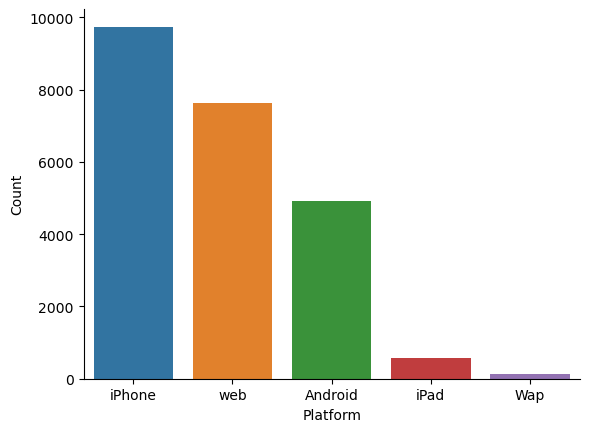

In [374]:
sns.barplot(data=taxi_count, x= 'platform', y= 'numbers')
plt.xlabel("Platform")
plt.ylabel("Count")
sns.despine()

### Question 7: Visualize the distribution of 'end_state' for each platform using the sns.countplot function and the hue parameter.

<Axes: xlabel='source', ylabel='count'>

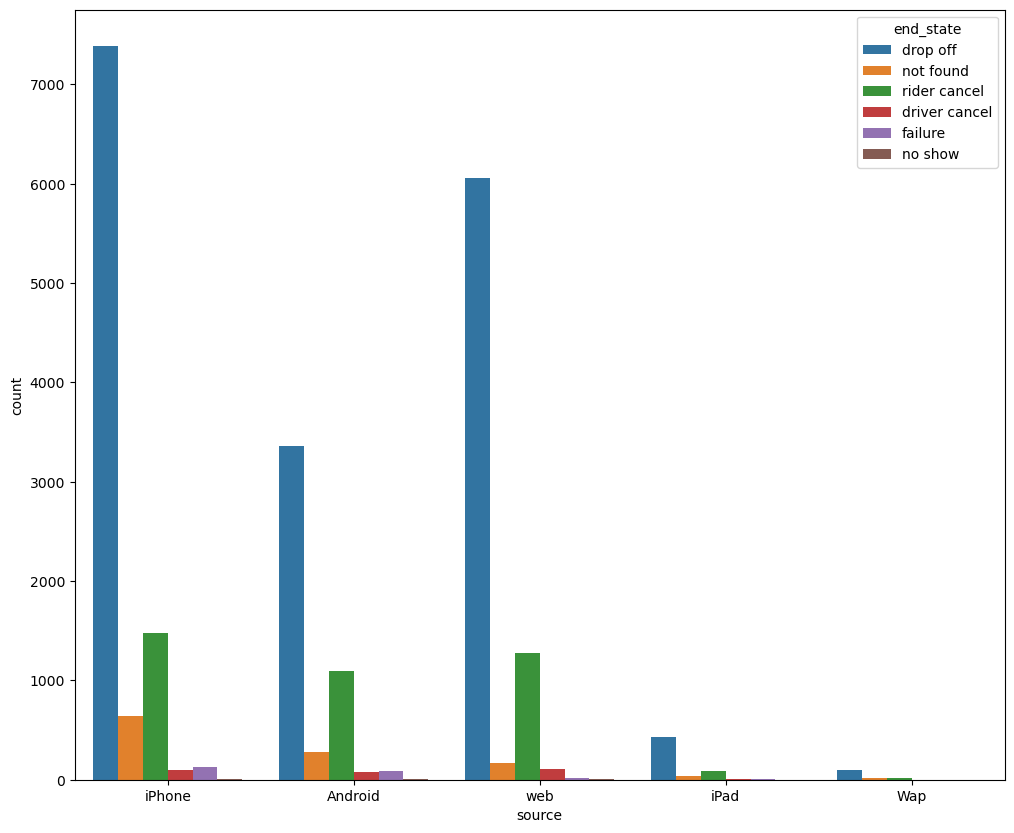

In [375]:
plt.figure(figsize=(12,10))
sns.countplot(data=taxi, hue='end_state', x='source')

In [376]:
# Some conclusions:
#  - Most orders with the status 'drop off' were made on the iPhone.
#  - The number of 'rider cancel' orders is lower on Android than on iPhone.
#  - The largest difference between the number of 'drop off' and 'rider cancel' orders is observed on the iPhone.


### Question 8: Check how the driver's scores are distributed and plot a pie chart to show the share of each score value.

In [377]:
taxi.columns

Index(['journey_id', 'user_id', 'start_type', 'start_lat', 'start_lon',
       'source', 'driver_score', 'driver_id', 'taxi_id', 'icon', 'start_at',
       'end_at', 'end_lat', 'end_lon', 'end_state', 'driver_start_lat',
       'driver_start_lon', 'arrived_at', 'rider_score'],
      dtype='object')

In [378]:
driver_score_counts = taxi.driver_score.value_counts(normalize=True)\
                        .mul(100)\
                        .round(2)\
                        .reset_index()\
                        .rename(columns={'driver_score':'percentage', 'proportion':'driver_score'})\
                        .sort_values('driver_score', ascending=False)
driver_score_counts
                        

,percentage,driver_score
0,5.0,58.81
1,4.0,21.88
2,0.0,14.30
3,3.0,2.97
4,1.0,1.23
5,2.0,0.81


In [379]:
pie_chart = driver_score_counts.sort_values('percentage', ascending = False, inplace = True)
pie_chart

([<matplotlib.patches.Wedge at 0x263bd4e3e50>,
 [Text(-0.9526279613277876, 0.5499999702695114, '58.81'),
  Text(-0.22870274572881877, -1.075962385074915, '21.88'),
  Text(1.04616222202798, -0.3399185272995272, '2.97'),
  Text(0.8174591679012434, 0.7360438226180605, '0.81'),
  Text(0.22870261980523157, 1.075962411840778, '1.23'),
  Text(-2.5747358194012124e-07, 1.09999999999997, '14.3')])

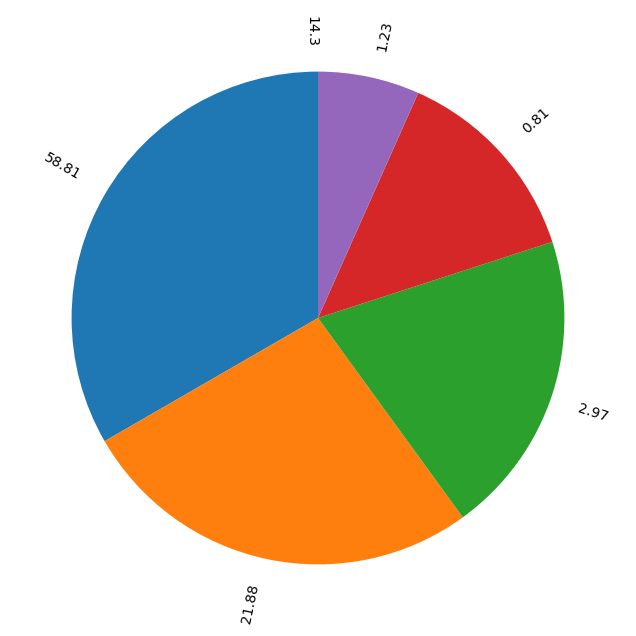

In [380]:
plt.figure(figsize=(8, 8))
plt.pie(driver_score_counts['percentage'], 
        startangle=90, 
        labels=driver_score_counts['driver_score'], 
        rotatelabels=True)

### Question 9: Compare this distribution with the distribution of driver's scores

In [381]:
taxi.columns

Index(['journey_id', 'user_id', 'start_type', 'start_lat', 'start_lon',
       'source', 'driver_score', 'driver_id', 'taxi_id', 'icon', 'start_at',
       'end_at', 'end_lat', 'end_lon', 'end_state', 'driver_start_lat',
       'driver_start_lon', 'arrived_at', 'rider_score'],
      dtype='object')

In [382]:
rider_score_count = taxi.rider_score.value_counts(normalize=True)\
                                        .mul(100)\
                                        .round(2)\
                                        .reset_index()\
                                        .rename(columns={'rider_score':'percentage', 'proportion':'rider_score'})\
                                        .sort_values('rider_score', ascending=False)
rider_score_count

,percentage,rider_score
0,5.0,87.10
1,4.0,8.83
2,0.0,2.29
3,3.0,1.38
4,1.0,0.21
5,2.0,0.19


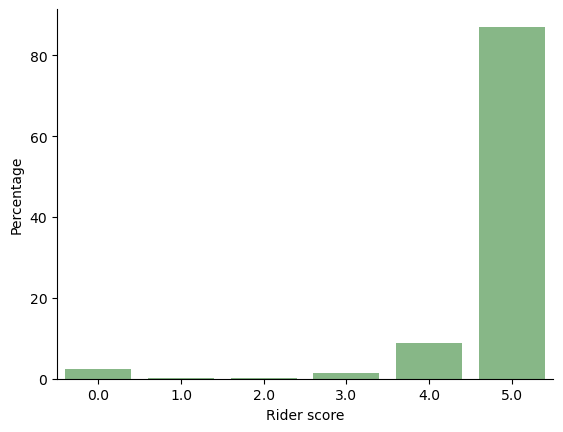

In [383]:
ax = sns.barplot(x='percentage', y='rider_score', data=rider_score_count, color='green', alpha=0.5)
ax.set(xlabel='Rider score', ylabel='Percentage');
sns.despine()
plt.show()

In [384]:
# Some concluision:
# In more than 80% of cases, drivers gave customers a 5-star rating.
# Drivers give fewer 0 ratings than customers.

### Question 10: How long do passengers have to wait for a taxi?


In [385]:
taxi[['start_at', 'end_at', 'arrived_at']].head()

,start_at,end_at,arrived_at
0,2010-11-16 16:44:00,2010-11-16 17:29:00,2010-11-16 17:02:00
1,2010-06-01 00:34:00,2010-06-01 00:37:00,NaN
2,2010-05-31 05:01:00,2010-05-31 05:04:00,NaN
3,2010-06-01 00:29:00,2010-06-01 00:32:00,NaN
4,2010-09-11 23:55:00,2010-09-12 01:07:00,2010-09-11 23:50:00


In [386]:
taxi[['start_at', 'end_at', 'arrived_at']] = taxi[['start_at', 'end_at', 'arrived_at']].apply(pd.to_datetime)

In [387]:
taxi[['start_at', 'end_at', 'arrived_at']].head()

,start_at,end_at,arrived_at
0,2010-11-16 16:44:00,2010-11-16 17:29:00,2010-11-16 17:02:00
1,2010-06-01 00:34:00,2010-06-01 00:37:00,NaT
2,2010-05-31 05:01:00,2010-05-31 05:04:00,NaT
3,2010-06-01 00:29:00,2010-06-01 00:32:00,NaT
4,2010-09-11 23:55:00,2010-09-12 01:07:00,2010-09-11 23:50:00


In [388]:
taxi.dtypes

journey_id                  object
user_id                     object
start_type                  object
start_lat                   object
start_lon                   object
source                      object
driver_score               float64
driver_id                   object
taxi_id                     object
icon                        object
start_at            datetime64[ns]
end_at              datetime64[ns]
end_lat                     object
end_lon                     object
end_state                   object
driver_start_lat            object
driver_start_lon            object
arrived_at          datetime64[ns]
rider_score                float64
dtype: object

In [389]:
taxi_query = taxi.query("start_type=='asap' or start_type=='reserved'")
taxi_query.head()

,journey_id,user_id,start_type,start_lat,start_lon,source,driver_score,driver_id,taxi_id,icon,start_at,end_at,end_lat,end_lon,end_state,driver_start_lat,driver_start_lon,arrived_at,rider_score
0,23a1406fc6a11d866e3c82f22eed4d4c,0e9af5bbf1edfe591b54ecdfd7e91e26,asap,"-12,13983536","-77,02355957",iPhone,5.0,583949a89a9ee17d19e3ca4f137b6b4c,b12f4f09c783e29fe0d0ea624530db56,executive,2010-11-16 16:44:00,2010-11-16 17:29:00,"-12,05537033","-77,0413208",drop off,"-12,10825481","-77,0272739",2010-11-16 17:02:00,5.0
1,dd2af4715d0dc16eded53afc0e243577,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13874817","-76,99536133",iPhone,NaN,NaN,NaN,executive,2010-06-01 00:34:00,2010-06-01 00:37:00,"-12,12465668","-77,02886963",not found,NaN,NaN,NaT,NaN
2,dd91e131888064bf7df3ce08f3d4b4ad,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,12453079","-77,02780151",iPhone,NaN,NaN,NaN,executive,2010-05-31 05:01:00,2010-05-31 05:04:00,"-12,13883209","-76,99530029",not found,NaN,NaN,NaT,NaN
3,dd2af4715d0dc16eded53afc0e2466d0,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13885117","-76,99530029",iPhone,NaN,NaN,NaN,executive,2010-06-01 00:29:00,2010-06-01 00:32:00,"-12,12458801","-77,02896118",not found,NaN,NaN,NaT,NaN
4,85b7eabcf5d84e42dc7629b7d27781af,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,08995438","-76,92626953",iPhone,4.0,d665fb9f75ef5d9cd0fd89479380ba78,0accdd3aa5a322f4129fa20b53278c69,executive,2010-09-11 23:55:00,2010-09-12 01:07:00,"-12,02223206","-77,10638428",drop off,"-12,08311558","-76,9277072",2010-09-11 23:50:00,5.0


In [390]:
taxi['wait_time'] = taxi['arrived_at'] - taxi['start_at']
taxi['wait_time'].median()

Timedelta('0 days 00:05:00')

In [391]:
print(f"How long do passengers have to wait for a taxi?")
print(f"Passengers wait approximately {taxi['wait_time'].median()} minutes on average.")

How long do passengers have to wait for a taxi?
Passengers wait approximately 0 days 00:05:00 minutes on average.


### Question 11: Define the driver’s ID who is most often late to orders that were made in advance (reserved).

In [392]:
on_time = pd.to_timedelta(0)
on_time

Timedelta('0 days 00:00:00')

In [393]:
late_driver = taxi.query('start_type == "reserved" and wait_time > @on_time', engine='python').driver_id.value_counts().idxmax()

In [394]:
print(f"The most often late to orders driver is {late_driver }")

The most often late to orders driver is 406921adcca37705ef527b4246c0cfea


### Question 12: What factors might influence the number of times a driver is late?

In [395]:
#define the top 5 drivers by trip count.
journeys = taxi.groupby('driver_id', as_index = False)\
               .agg({'journey_id':'nunique'})\
               .sort_values('journey_id', ascending = False)\
               .rename(columns = {'journey_id':'journey_num'})
journeys.head()

,driver_id,journey_num
129,c814db2127582cf95dea1f74f43127c2,1523
139,d665fb9f75ef5d9cd0fd89479380ba78,1225
167,ff5c924e0b630fd7c019a4234059fdf4,1111
38,406921adcca37705ef527b4246c0cfea,1075
148,ec84a73745199ff840ecafcb924383ad,974


In [396]:
# our driver ranked fourth

In [397]:
# compare with the top 'lates' drivers
delays = taxi.query('start_type == "reserved" and wait_time > @on_time', engine='python')\
    .groupby('driver_id', as_index = False)\
    .agg({'journey_id':'nunique'})\
    .sort_values('journey_id', ascending = False)\
    .rename(columns = {'journey_id':'delay_num'})
delays.head()

,driver_id,delay_num
24,406921adcca37705ef527b4246c0cfea,67
86,d665fb9f75ef5d9cd0fd89479380ba78,59
93,ec84a73745199ff840ecafcb924383ad,57
29,56f59b58bcbbd1cdabc3652e713134c2,51
77,c814db2127582cf95dea1f74f43127c2,45


In [398]:
# four drivers appear in both top lists, 
# this makes sense – the more a driver drives, 
# the more likely they are to be late.

In [399]:
journeys_delays = journeys.merge(delays, on = 'driver_id')

In [400]:
journeys_delays['late_score'] = round(100 * journeys_delays.delay_num / journeys_delays.journey_num)

In [401]:
journeys_delays.sort_values('delay_num', ascending = False).head()

,driver_id,journey_num,delay_num,late_score
3,406921adcca37705ef527b4246c0cfea,1075,67,6.0
1,d665fb9f75ef5d9cd0fd89479380ba78,1225,59,5.0
4,ec84a73745199ff840ecafcb924383ad,974,57,6.0
13,56f59b58bcbbd1cdabc3652e713134c2,481,51,11.0
0,c814db2127582cf95dea1f74f43127c2,1523,45,3.0


In [402]:
journeys_delays.late_score.describe()

count    105.000000
mean      10.133333
std       10.441289
min        1.000000
25%        4.000000
50%        7.000000
75%       12.000000
max       67.000000
Name: late_score, dtype: float64

In [403]:
# from the above analysis, I think our driver was late in roughly 6% of cases, 
# while half of the drivers were late in more than 7% of their orders. 
# To sum up: based on this analysis, it seems that all delays are dependent 
# on the number of orders.

### Question 13: Add two new columns: month, which will store the number of the month when the order was made and weekday. Plot a chart showing order counts by month and identify the month with the lowest number of orders during the summer months. Define which day of the week has the fewest orders.

In [404]:
taxi['month'] = taxi.start_at.dt.month
taxi['weekday'] = taxi.start_at.dt.day_name()
taxi[['start_at', 'month', 'weekday']].head()

,start_at,month,weekday
0,2010-11-16 16:44:00,11,Tuesday
1,2010-06-01 00:34:00,6,Tuesday
2,2010-05-31 05:01:00,5,Monday
3,2010-06-01 00:29:00,6,Tuesday
4,2010-09-11 23:55:00,9,Saturday


<Axes: xlabel='month', ylabel='count'>

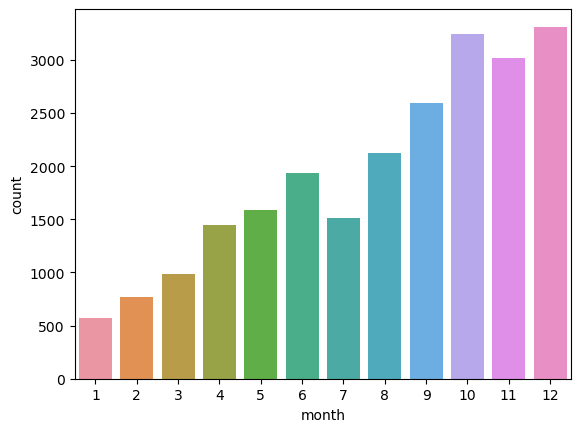

In [405]:
sns.countplot(data=taxi, x='month')

<Axes: xlabel='weekday', ylabel='count'>

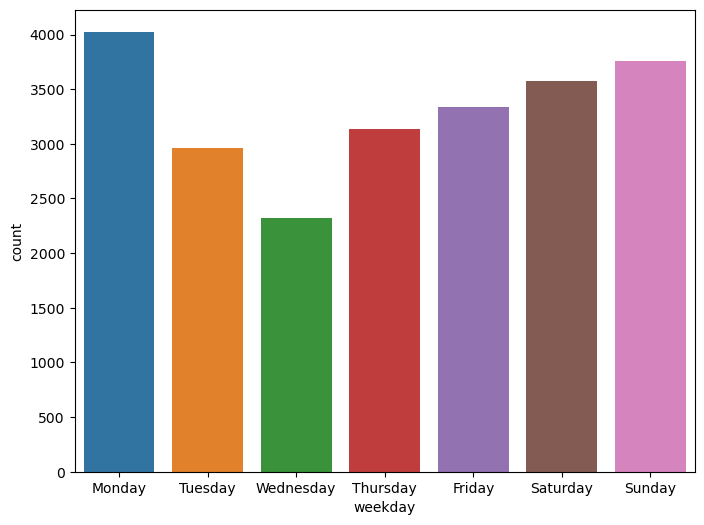

In [406]:
plt.figure(figsize=(8,6))
sns.countplot(data=taxi, x='weekday', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

In [407]:
print(f"July had the lowest number of orders during the summer months")
print(f"Wednesday is the 'worst' day for orders")

July had the lowest number of orders during the summer months
Wednesday is the 'worst' day for orders


### Question 14: Calculate the DAU, WAU, and MAU metrics

<Axes: title={'center': 'Monthly Active Users (MAU)'}, xlabel='month'>

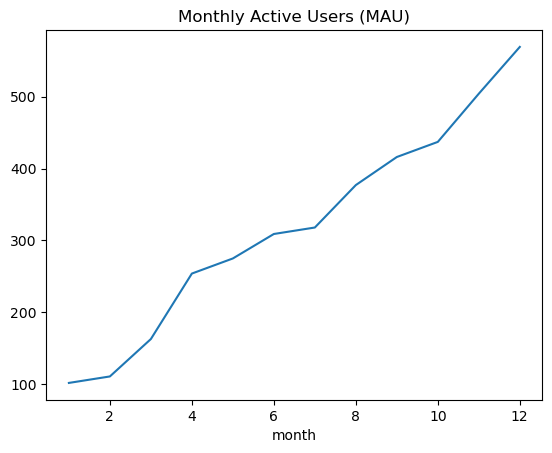

In [408]:
mau = taxi.groupby('month').user_id.nunique()
mau.plot.line(title="Monthly Active Users (MAU)")

In [409]:
taxi.head()

,journey_id,user_id,start_type,start_lat,start_lon,source,driver_score,driver_id,taxi_id,icon,...,end_lat,end_lon,end_state,driver_start_lat,driver_start_lon,arrived_at,rider_score,wait_time,month,weekday
0,23a1406fc6a11d866e3c82f22eed4d4c,0e9af5bbf1edfe591b54ecdfd7e91e26,asap,"-12,13983536","-77,02355957",iPhone,5.0,583949a89a9ee17d19e3ca4f137b6b4c,b12f4f09c783e29fe0d0ea624530db56,executive,...,"-12,05537033","-77,0413208",drop off,"-12,10825481","-77,0272739",2010-11-16 17:02:00,5.0,0 days 00:18:00,11,Tuesday
1,dd2af4715d0dc16eded53afc0e243577,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13874817","-76,99536133",iPhone,NaN,NaN,NaN,executive,...,"-12,12465668","-77,02886963",not found,NaN,NaN,NaT,NaN,NaT,6,Tuesday
2,dd91e131888064bf7df3ce08f3d4b4ad,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,12453079","-77,02780151",iPhone,NaN,NaN,NaN,executive,...,"-12,13883209","-76,99530029",not found,NaN,NaN,NaT,NaN,NaT,5,Monday
3,dd2af4715d0dc16eded53afc0e2466d0,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13885117","-76,99530029",iPhone,NaN,NaN,NaN,executive,...,"-12,12458801","-77,02896118",not found,NaN,NaN,NaT,NaN,NaT,6,Tuesday
4,85b7eabcf5d84e42dc7629b7d27781af,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,08995438","-76,92626953",iPhone,4.0,d665fb9f75ef5d9cd0fd89479380ba78,0accdd3aa5a322f4129fa20b53278c69,executive,...,"-12,02223206","-77,10638428",drop off,"-12,08311558","-76,9277072",2010-09-11 23:50:00,5.0,-1 days +23:55:00,9,Saturday


<Axes: title={'center': 'Daily Active Users (DAU)'}, xlabel='arrived_at'>

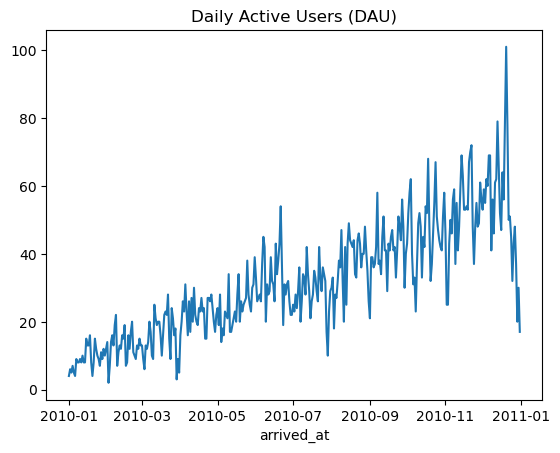

In [410]:
taxi['arrived_at'] = pd.to_datetime(taxi['arrived_at'])

dau = taxi.groupby(taxi['arrived_at'].dt.date)['user_id'].nunique()

dau.plot.line(title="Daily Active Users (DAU)")


<Axes: title={'center': 'Weekly Active Users (WAU)'}, xlabel='arrived_at'>

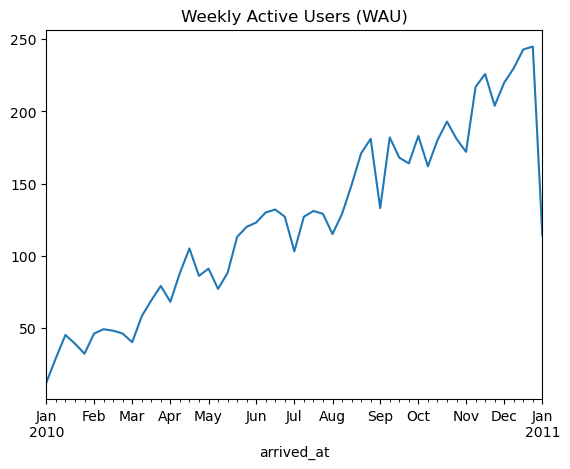

In [411]:
wau = taxi.groupby(taxi['arrived_at'].dt.to_period('W'))['user_id'].nunique()

wau.plot.line(title="Weekly Active Users (WAU)")


In [412]:
# some observations

# DAU: Significant fluctuations at the end of the year, overall growth.
# WAU: Sharp increase in December, steady growth throughout the year.
# MAU: In April, the number is approximately 2.5 times higher than in January.